In [1]:
# Imports
import run_fair
import utils_plotting

%load_ext autoreload
%autoreload 2

### Notebook for generating all sets of training, validation, test data for a Neural Network emulator of FaIR

#### 1. ScenarioMIP for CMIP7
ScenarioMIP for CMIP7 consists of a set of scenarios that represent plausible future emissions pathways separated into sets by priority, either high (tier 1) and low (tier 2). Although all scenarios are requested to be run from 2025-2150, each scenario also has a long-term extension from 2150-2500; there is also a <i> historical </i> scenario using historical emissions data from 1750-2024 (FaIR specifically runs starting at 1750, while ESMs typically start in 1850). Only two extensions are part of tier 1: the <i>High</i> and <i> Very Low with Limited Overshoot. </i> For this work, we consider only emissions-driven scenarios, and the full list of scenarios is below.

<ol>
  <li> Tier 1</li>
  <ol>
    <li> High w/ Extension (H-ext) </li>
    <li> Medium (M) </li>
    <li> Medium-Low (ML) </li>
    <li> Low (L) </li>
    <li> Very Low with Limited Overshoot w/ Extension (VLLO-ext)</li>
    <li> Very Low after High Overshoot (VLHO)</li>
  </ol>
  <li> Tier 2</li>
  <ol>
    <li> High Overshoot w/ Extension (H-ext-OS) </li>
    <li> Medium w/ Extension (M-ext) </li>
    <li> Medium-Low w/ Extension (ML-ext) </li>
    <li> Low w/ Extension (L-ext) </li>
    <li> Very Low after High Overshoot w/ Extension (VLHO-ext) </li>
  </ol>
</ol>

We split these data as follows: (1) We use tier 1 scenarios to train our baseline emulator based on the assumption that all modeling centers will run these scenarios. (2) Also based on this assumption, we use tier 1 scenarios as the target of our Bayesian optimization to find the optimal parameter set for our theoretically optimal emulator training scenario. (3) We then test both emulators against the full set of tier 2 scenarios.

In [2]:
# Generate tier 1 and tier 2 scenarios
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())

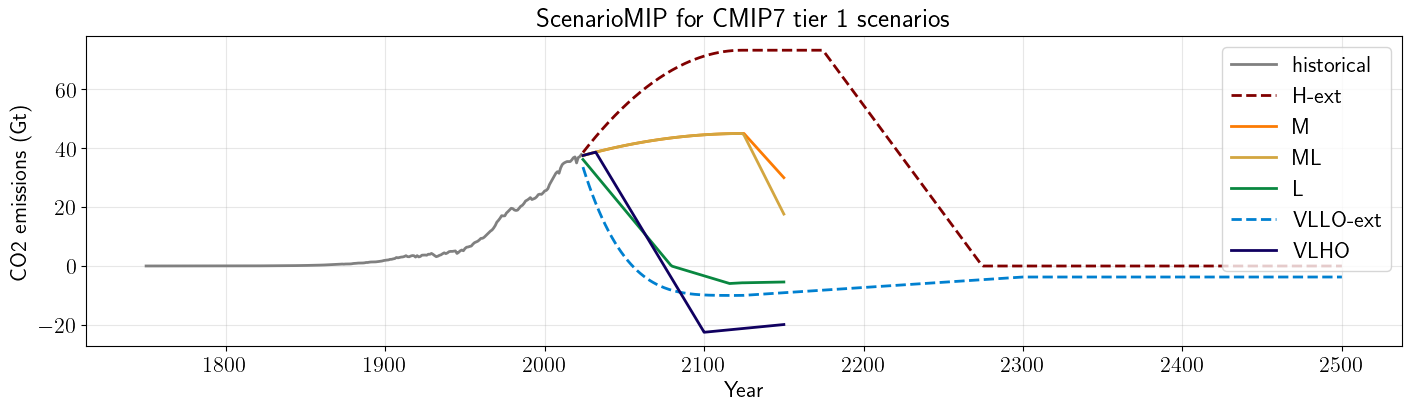

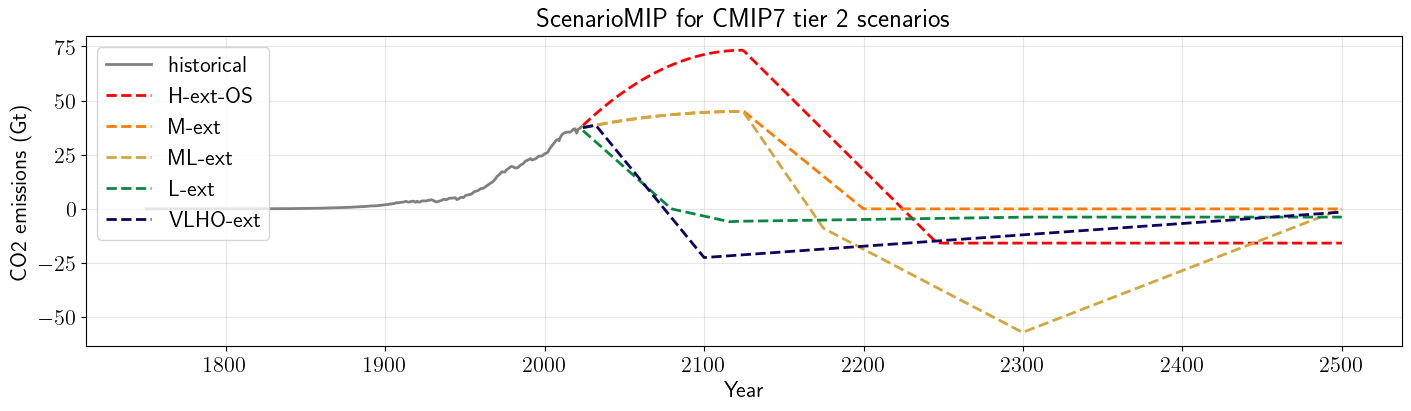

In [8]:
# Plot emissions scenarios (optional)
agent = 'CO2'
utils_plotting.plot_emissions(emis_dict_tier1, agent, 'ScenarioMIP for CMIP7 tier 1')
utils_plotting.plot_emissions(emis_dict_tier2, agent, 'ScenarioMIP for CMIP7 tier 2')

In [5]:
# Run FaIR for each scenario to get temperature change
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')

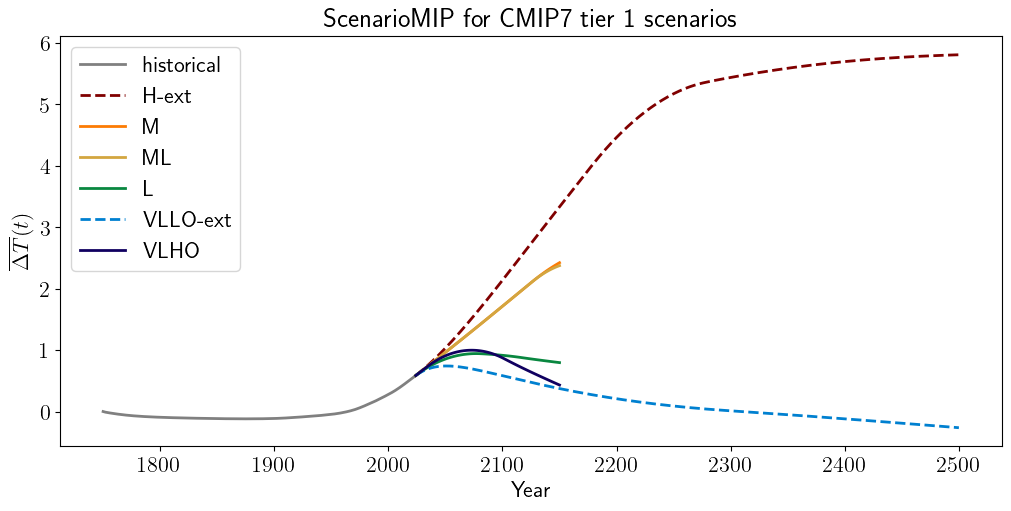

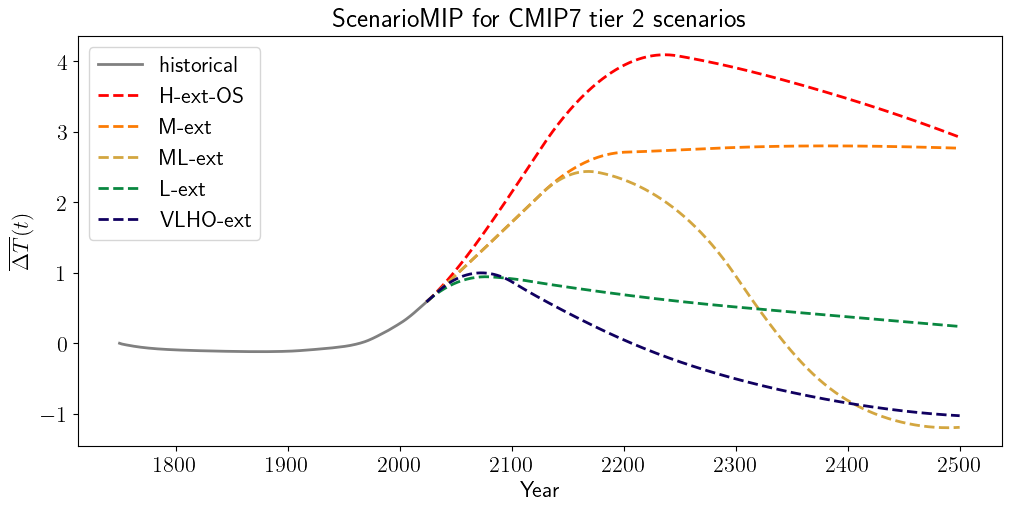

In [6]:
# Plot temperature change (optional)
utils_plotting.plot_delT(delT_dict_tier1, scenarios_tier1, 'ScenarioMIP for CMIP7 tier 1')
utils_plotting.plot_delT(delT_dict_tier2, scenarios_tier2, 'ScenarioMIP for CMIP7 tier 2')

#### 2. DECK for CMIP7, includes custom scenarios

In [3]:
# Generate DECK scenarios (includes custom scenarios e.g. abrupt-4xCH4)
agents = ['Sulfur','BC']
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())

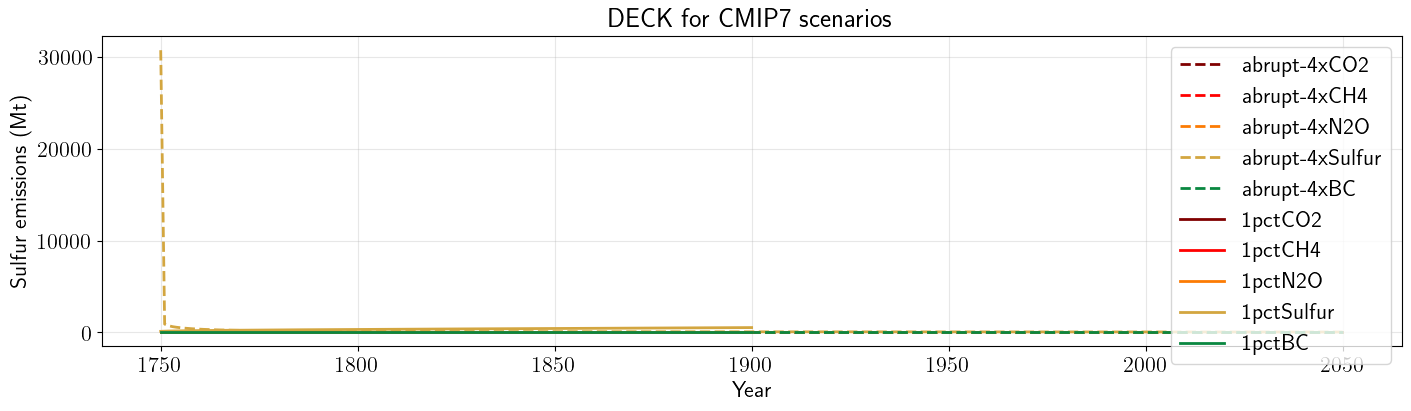

In [4]:
# Plot emissions scenarios (optional; sanity check, most emissions should = 0)
agent = 'Sulfur'
utils_plotting.plot_emissions(emis_dict_DECK, agent, 'DECK for CMIP7', MIP='DECK')

In [18]:
# Run FaIR for each scenario to get temperature change
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')

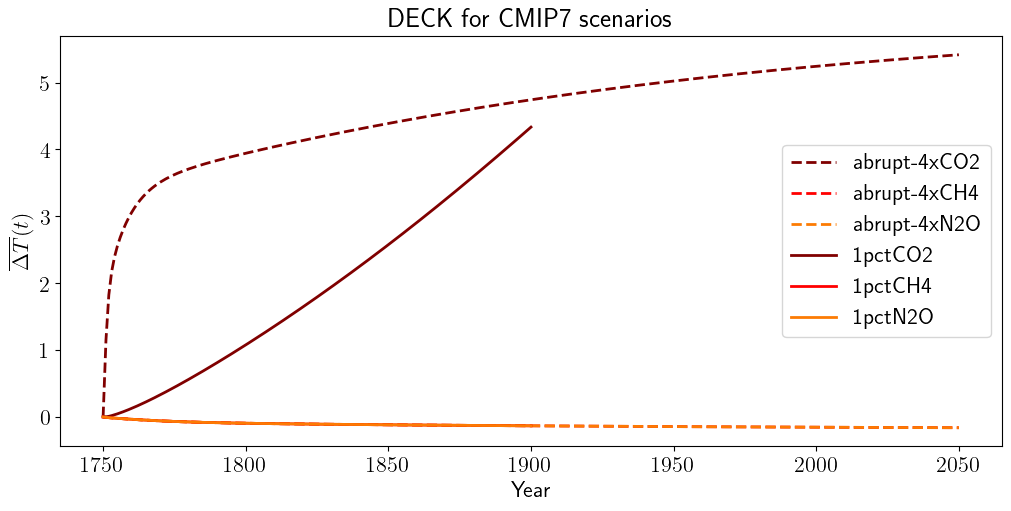

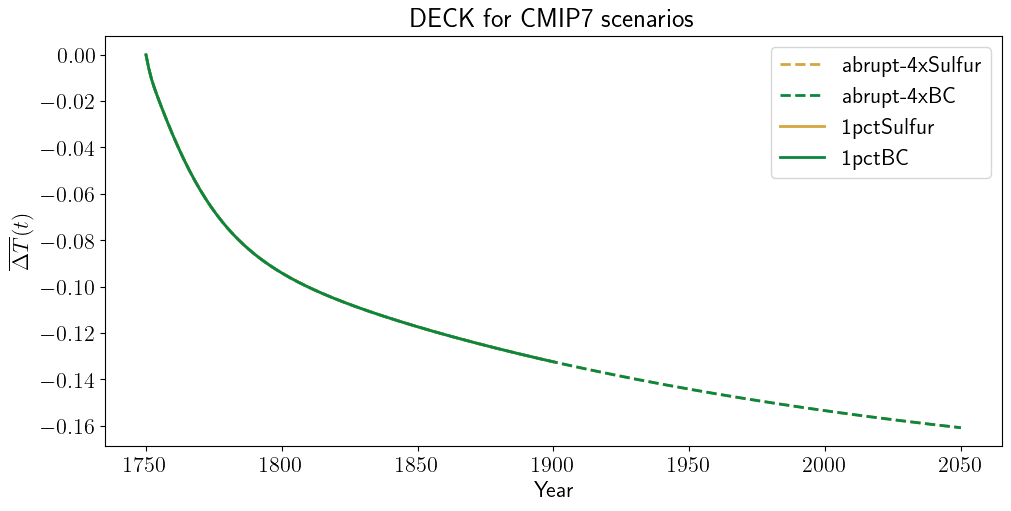

In [19]:
# Plot temperature change (optional)
well_mixed = ['abrupt-4xCO2','abrupt-4xCH4','abrupt-4xN2O',
              '1pctCO2','1pctCH4','1pctN2O']
aerosols = ['abrupt-4xSulfur','abrupt-4xBC',
            '1pctSulfur','1pctBC']
utils_plotting.plot_delT(delT_dict_DECK, well_mixed, 'DECK for CMIP7', MIP='DECK')
utils_plotting.plot_delT(delT_dict_DECK, aerosols, 'DECK for CMIP7', MIP='DECK')

#### 3. GeoMIP for CMIP6

In [26]:
# Generate GeoMIP scenarios
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_geoMIP = run_fair.load_geoMIP_CMIP6(agents, emis_dict_tier1)
scenarios_geoMIP = list(emis_dict_geoMIP.keys())

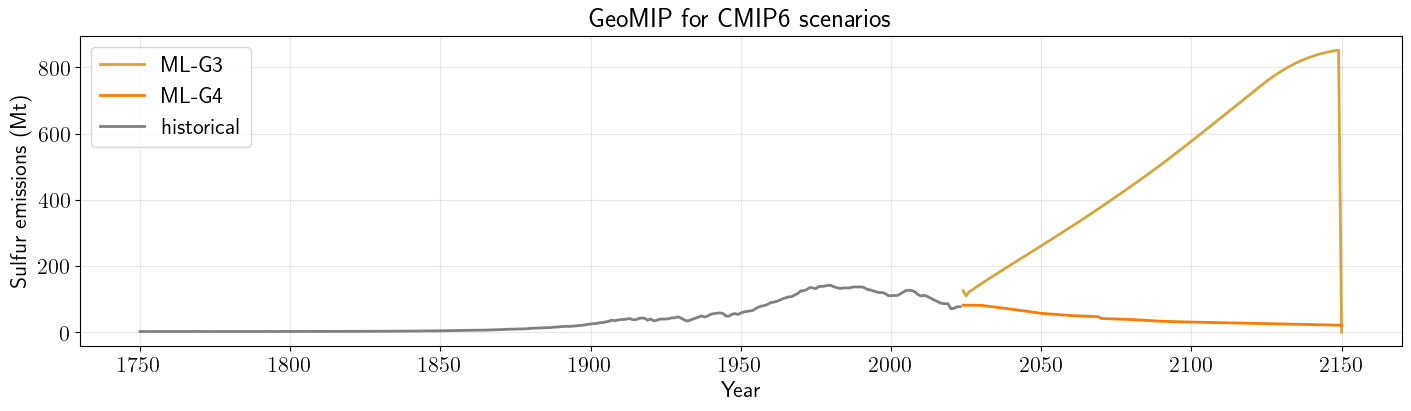

In [27]:
# Plot emissions scenarios (optional)
agent = 'Sulfur'
utils_plotting.plot_emissions(emis_dict_geoMIP, agent, 'GeoMIP for CMIP6', MIP='GeoMIP')

In [28]:
# Run FaIR for each scenario to get temperature change
delT_dict_geoMIP = run_fair.get_delT(emis_dict_geoMIP, scenarios_geoMIP, agents)

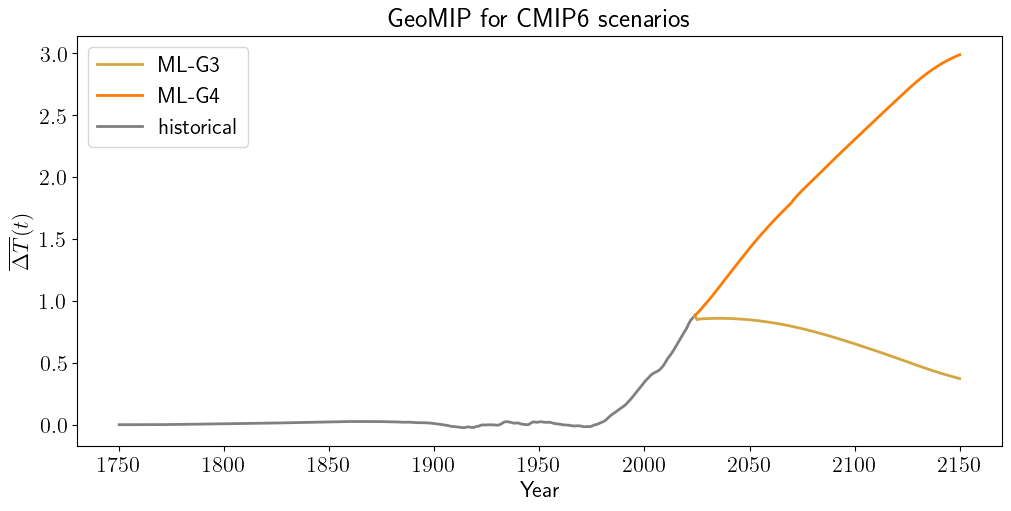

In [29]:
utils_plotting.plot_delT(delT_dict_geoMIP, scenarios_geoMIP, 'GeoMIP for CMIP6', MIP='GeoMIP')

### 4. CS3 Global Change Outlook 2025

In [124]:
# Generate CS3 scenarios
agents = ['CO2']#,'CH4','N2O','Sulfur','BC']
emis_dict_CS3 = run_fair.load_CS3(agents, emis_dict_tier1)
scenarios_CS3 = list(emis_dict_CS3.keys())

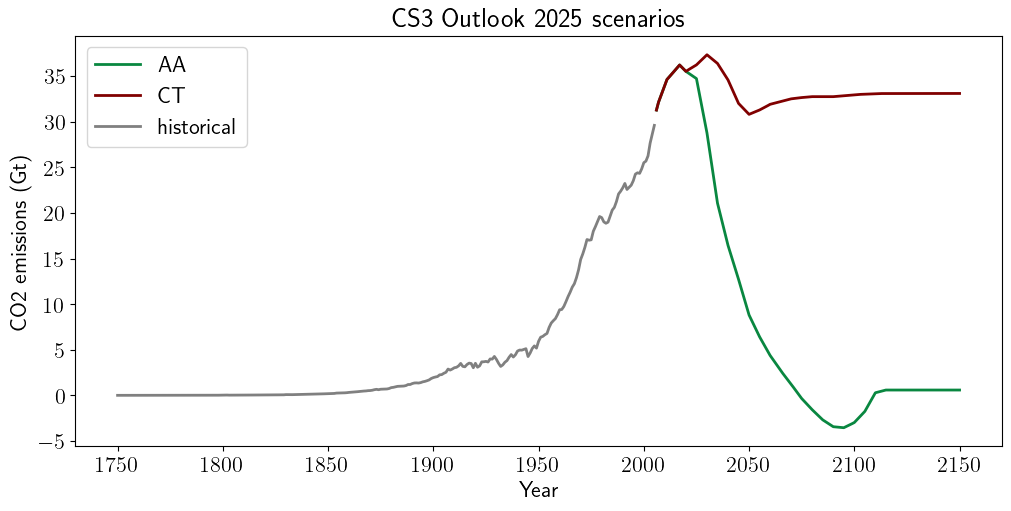

In [125]:
# Plot emissions scenarios (optional)
agent = 'CO2'
utils_plotting.plot_emissions(emis_dict_CS3, agent, 'CS3 Outlook 2025', MIP='CS3')

In [126]:
# Run FaIR for each scenario to get temperature change
delT_dict_CS3 = run_fair.get_delT(emis_dict_CS3, scenarios_CS3, agents, MIP='CS3')

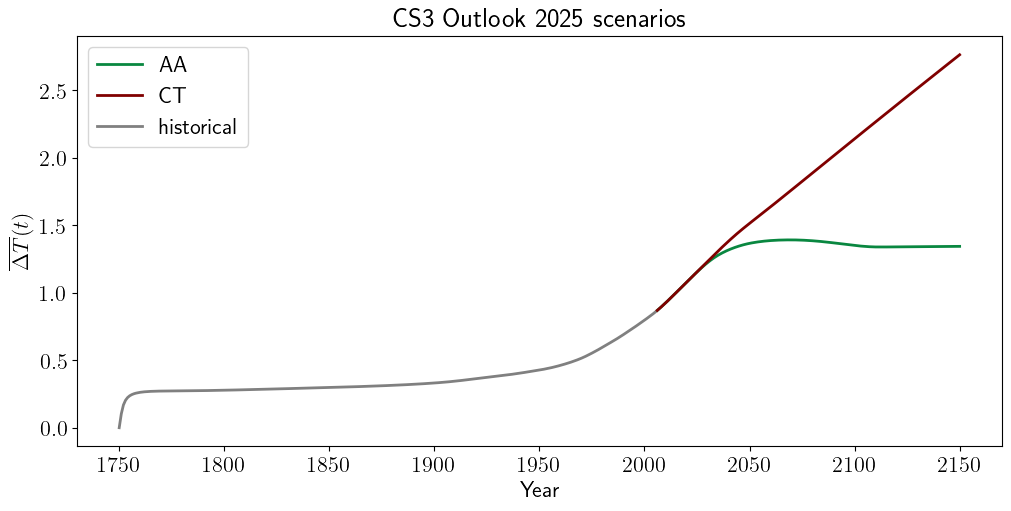

In [127]:
# Plot temperature change (optional)
utils_plotting.plot_delT(delT_dict_CS3, scenarios_CS3, 'CS3 Outlook 2025', MIP='CS3')